# Notebook 03: Feature Engineering
This notebook extracts 15 acoustic feature channels (including Mel-spectrogram, Chroma, RIR features, Breathing features) and fuses them.

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.features import (
    compute_spectrogram,
    compute_mel_spectrogram,
    compute_mfcc,
    extract_spectral_features,
    extract_chroma,
    extract_rms_energy,
    extract_rir_features,
    extract_breathing_features,
    extract_waveform_features,
    align_temporal_dimension,
    standardize_features,
    fuse_features,
)
print("Feature extraction modules loaded successfully!")


Feature extraction modules loaded successfully!


In [2]:
processed_metadata_path = 'datasets/processed/preprocessed_metadata.csv'
if not os.path.exists(processed_metadata_path):
    # Run a quick generation if not present
    raise FileNotFoundError("Please execute Notebook 02 first to generate cached waveforms!")

df_processed = pd.read_csv(processed_metadata_path)
print(f"Loaded {len(df_processed)} preprocessed audio records.")


Loaded 100 preprocessed audio records.


In [3]:
fused_features_list = []
labels_list = []

for idx, row in df_processed.iterrows():
    y_np = np.load(row['processed_path'])
    y = torch.tensor(y_np)
    label = 0 if row['key'] == 'bonafide' else 1
    
    # Extract features
    mfcc = compute_mfcc(y, sample_rate=16000, n_mfcc=13)
    mel = compute_mel_spectrogram(y, sample_rate=16000, n_mels=64)
    chroma = extract_chroma(y, sample_rate=16000)
    spectral = extract_spectral_features(y, sample_rate=16000)
    rms = extract_rms_energy(y)
    rir = extract_rir_features(y, sample_rate=16000)
    breath = extract_breathing_features(y, sample_rate=16000)
    wave_stats = extract_waveform_features(y)
    
    # Fuse features (align along time-step dimension)
    fused = fuse_features([mfcc, mel, chroma, spectral, rms, rir, breath, wave_stats], target_time_steps=100)
    fused_features_list.append(fused.cpu().numpy())
    labels_list.append(label)

X = np.stack(fused_features_list, axis=0) # shape [N, channels, features, time_steps]
y = np.array(labels_list)

# Reshape to 2D for traditional classifiers [N, features * time_steps]
X_flat = X.reshape(X.shape[0], -1)

np.save('datasets/processed/X_features.npy', X)
np.save('datasets/processed/X_flat.npy', X_flat)
np.save('datasets/processed/y.npy', y)

print("Features extracted and saved! Shape of flat features:", X_flat.shape)


Features extracted and saved! Shape of flat features: (100, 11300)


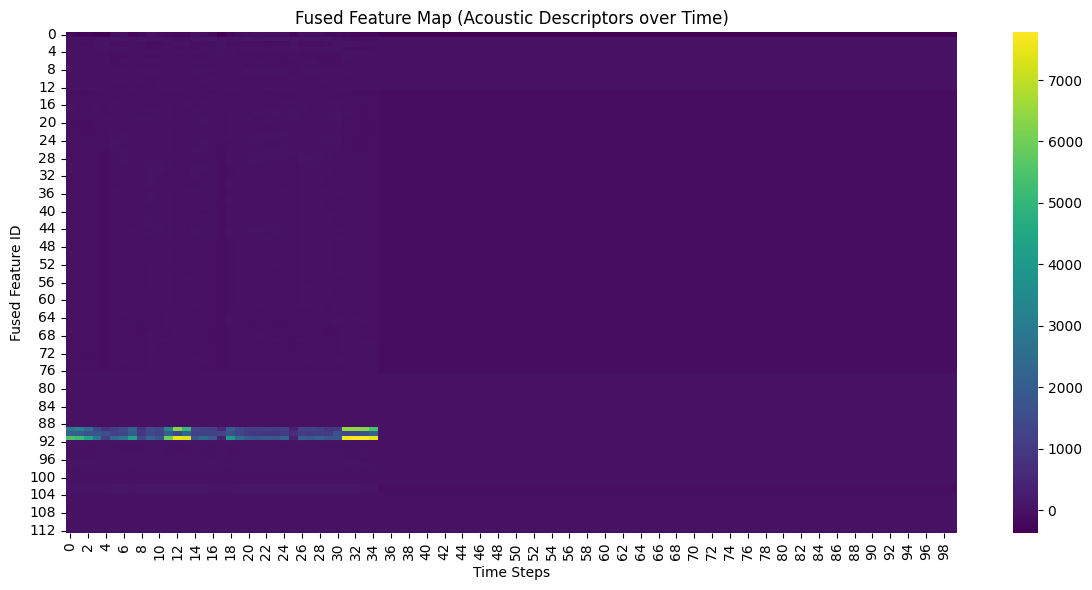

In [4]:
# Visualizing feature fusion
plt.figure(figsize=(12, 6))
sns.heatmap(X[0, 0], cmap='viridis')
plt.title("Fused Feature Map (Acoustic Descriptors over Time)")
plt.xlabel("Time Steps")
plt.ylabel("Fused Feature ID")
plt.tight_layout()
plt.savefig('plots/fused_feature_heatmap.png', dpi=300)
plt.show()
